In [158]:
### makeClassifierTrainingDataset.py ###


In [159]:
import os
import numpy as np
import pandas as pd
from tensorflow.compiler.tf2xla.python.xla import concatenate
from tensorflow.keras.models import load_model
import seaborn as sns
import matplotlib.pyplot as plt
os.chdir(r'C:\snake2-beta-insa-main/data/teamExperiments')
from makeClassifierTrainingSet import *
from attackDopel import *


In [160]:
# Chemin du modèle LSTM
model_path = "results/lstm_model_task3.keras"


In [161]:
# Charger le modèle LSTM
lstm_model = load_model(model_path)

def create_sequences(data, input_steps):
    sequences = []
    for i in range(len(data) - input_steps + 1):
        seq = data[i:i + input_steps]
        sequences.append(seq)
    return np.array(sequences)

taskNumber = 3


In [162]:
# Réinitialisation des DataFrames
nonMemberPart = pd.DataFrame()
memberPart = pd.DataFrame()
trainingSet = pd.DataFrame()


In [163]:
# Charger les données publiques et générer les colonnes 8, 9, 10
print("Chargement des données publiques et génération des colonnes 8, 9, 10...")
public_data = publicData_Tasks34
columns_1_to_7 = public_data.iloc[:, :7]
columns_4_to_7 = public_data.iloc[:,3:7:]
public_data


Chargement des données publiques et génération des colonnes 8, 9, 10...


,0,1,2,3,4,5,6
0,0.278411,0.306231,0.324308,0.304473,0.381296,0.280441,0.295669
1,0.493030,0.166449,0.489575,0.491742,0.561079,0.363340,0.450361
2,0.666707,0.316913,0.240469,0.446466,0.631856,0.595188,0.599279
3,0.245833,0.400479,0.365355,0.409176,0.359795,0.146433,0.366022
4,0.031366,0.000000,0.116750,0.000000,0.220301,0.000000,0.000000
...,...,...,...,...,...,...,...
568466,0.297124,0.195315,0.232635,0.525608,0.409782,0.197542,0.209967
568467,0.070610,0.042351,0.145842,0.016668,0.000000,0.075762,0.000000
568468,0.325277,0.399433,0.634069,0.339490,0.187966,0.481256,0.357522
568469,0.254697,0.293821,0.312064,0.384341,0.175996,0.200012,0.150524


In [164]:
columns_1_to_7


,0,1,2,3,4,5,6
0,0.278411,0.306231,0.324308,0.304473,0.381296,0.280441,0.295669
1,0.493030,0.166449,0.489575,0.491742,0.561079,0.363340,0.450361
2,0.666707,0.316913,0.240469,0.446466,0.631856,0.595188,0.599279
3,0.245833,0.400479,0.365355,0.409176,0.359795,0.146433,0.366022
4,0.031366,0.000000,0.116750,0.000000,0.220301,0.000000,0.000000
...,...,...,...,...,...,...,...
568466,0.297124,0.195315,0.232635,0.525608,0.409782,0.197542,0.209967
568467,0.070610,0.042351,0.145842,0.016668,0.000000,0.075762,0.000000
568468,0.325277,0.399433,0.634069,0.339490,0.187966,0.481256,0.357522
568469,0.254697,0.293821,0.312064,0.384341,0.175996,0.200012,0.150524


In [165]:
columns_4_to_7.columns = [0,1,2,3,]
columns_4_to_7

,0,1,2,3
0,0.304473,0.381296,0.280441,0.295669
1,0.491742,0.561079,0.363340,0.450361
2,0.446466,0.631856,0.595188,0.599279
3,0.409176,0.359795,0.146433,0.366022
4,0.000000,0.220301,0.000000,0.000000
...,...,...,...,...
568466,0.525608,0.409782,0.197542,0.209967
568467,0.016668,0.000000,0.075762,0.000000
568468,0.339490,0.187966,0.481256,0.357522
568469,0.384341,0.175996,0.200012,0.150524


In [166]:

# Préparer les séquences pour LSTM
sequences = create_sequences(columns_4_to_7.values, input_steps=20)
generated_columns = lstm_model.predict(sequences, verbose=1)
generated_columns

17765/17765 ━━━━━━━━━━━━━━━━━━━━ 81s 5ms/step


array([[0.26391882, 0.25380617, 0.27854615],
       [0.28608382, 0.27065194, 0.28611547],
       [0.3205331 , 0.30068225, 0.3031965 ],
       ...,
       [0.2602208 , 0.25263917, 0.29123834],
       [0.2674023 , 0.25608355, 0.29005802],
       [0.23021515, 0.22841929, 0.2764051 ]], dtype=float32)

In [167]:
generated_df = pd.DataFrame(generated_columns, columns=["7", "8", "9"])
generated_df

,7,8,9
0,0.263919,0.253806,0.278546
1,0.286084,0.270652,0.286115
2,0.320533,0.300682,0.303196
3,0.290615,0.278987,0.288680
4,0.317300,0.301727,0.302144
...,...,...,...
568447,0.260928,0.250856,0.284772
568448,0.256403,0.248402,0.288719
568449,0.260221,0.252639,0.291238
568450,0.267402,0.256084,0.290058


In [168]:
complete_data = pd.concat([columns_4_to_7, generated_df], axis=1)
complete_data.columns=[0,1,2,3,4,5,6]
complete_data

,0,1,2,3,4,5,6
0,0.304473,0.381296,0.280441,0.295669,0.263919,0.253806,0.278546
1,0.491742,0.561079,0.363340,0.450361,0.286084,0.270652,0.286115
2,0.446466,0.631856,0.595188,0.599279,0.320533,0.300682,0.303196
3,0.409176,0.359795,0.146433,0.366022,0.290615,0.278987,0.288680
4,0.000000,0.220301,0.000000,0.000000,0.317300,0.301727,0.302144
...,...,...,...,...,...,...,...
568466,0.525608,0.409782,0.197542,0.209967,NaN,NaN,NaN
568467,0.016668,0.000000,0.075762,0.000000,NaN,NaN,NaN
568468,0.339490,0.187966,0.481256,0.357522,NaN,NaN,NaN
568469,0.384341,0.175996,0.200012,0.150524,NaN,NaN,NaN


In [169]:
output_path = "results/PublicSet_task3.csv"
trainingSet.to_csv(output_path, index=False)

In [170]:
# Création des parties membre et non-membre
privateDataset_Path = r"C:\snake2-beta-insa-main\data\teamExperiments\createdSets\Task 41\train"

print("Création des parties membre et non-membre...")
memberPart = makeMemberPart(privateDataset_Path, clean=False)
memberPart

Création des parties membre et non-membre...


,0,1,2,3,4,5,6
0,0.159767,0.100764,0.192436,0.174238,0.132963,0.156313,0.166843
1,0.000000,0.000000,0.356628,0.296685,0.326005,0.322944,0.217059
2,0.222589,0.453740,0.217210,0.165389,0.190239,0.353052,0.273577
3,0.460073,0.646463,0.512440,0.530850,0.521107,0.536502,0.644675
4,0.000000,0.192587,0.439345,0.551927,0.347339,0.354870,0.537533
...,...,...,...,...,...,...,...
14995,0.355703,0.275623,0.438587,0.362749,0.440360,0.435026,0.273274
14996,0.000000,0.000000,0.352143,0.275699,0.353006,0.278881,0.159722
14997,0.137190,0.091066,0.023183,0.116946,0.110279,0.182375,0.240424
14998,0.167813,0.065155,0.290245,0.445860,0.182208,0.252894,0.228499


In [171]:
nonMembers = pd.DataFrame()
allNonMembers = pd.concat([complete_data, memberPart, memberPart]).drop_duplicates(keep=False)
while len(nonMembers) < len(memberPart):
    rowToAdd = allNonMembers.sample()
    nonMembers = pd.concat([nonMembers, rowToAdd])

In [172]:
nonMembers

,0,1,2,3,4,5,6
287095,0.440027,0.226908,0.358507,0.361007,0.331961,0.313004,0.318216
106261,0.410828,0.313489,0.862067,0.532290,0.262179,0.260006,0.294372
40349,0.000000,0.691178,0.456937,0.462755,0.343402,0.310685,0.302494
101717,0.246985,0.055685,0.000000,0.150615,0.319628,0.305469,0.324346
433950,0.406464,0.222650,0.205694,0.354264,0.291859,0.279830,0.279662
...,...,...,...,...,...,...,...
152713,0.585020,0.696406,0.638342,0.575262,0.291773,0.278595,0.286858
293934,0.290002,0.000000,0.640812,0.256455,0.178862,0.195942,0.225985
207697,0.243121,0.204937,0.371841,0.155312,0.307747,0.290026,0.297451
175959,0.541927,0.675208,0.337505,0.581732,0.301695,0.287614,0.301652


In [173]:
# Créer le dataset d'entraînement final
print("Création du dataset d'entraînement final...")
trainingSet = createFinalTrainingSet(nonMembers, memberPart)
trainingSet

Création du dataset d'entraînement final...


,0,1,2,3,4,5,6,isMember
287095,0.440027,0.226908,0.358507,0.361007,0.331961,0.313004,0.318216,0
106261,0.410828,0.313489,0.862067,0.532290,0.262179,0.260006,0.294372,0
40349,0.000000,0.691178,0.456937,0.462755,0.343402,0.310685,0.302494,0
101717,0.246985,0.055685,0.000000,0.150615,0.319628,0.305469,0.324346,0
433950,0.406464,0.222650,0.205694,0.354264,0.291859,0.279830,0.279662,0
...,...,...,...,...,...,...,...,...
14995,0.355703,0.275623,0.438587,0.362749,0.440360,0.435026,0.273274,1
14996,0.000000,0.000000,0.352143,0.275699,0.353006,0.278881,0.159722,1
14997,0.137190,0.091066,0.023183,0.116946,0.110279,0.182375,0.240424,1
14998,0.167813,0.065155,0.290245,0.445860,0.182208,0.252894,0.228499,1


In [174]:
# Sauvegarder le dataset final
output_path = "results/trainingSet_task3.csv"
trainingSet.to_csv(output_path, index=False)
print(f"Dataset d’entraînement sauvegardé : {output_path}")


Dataset d’entraînement sauvegardé : results/trainingSet_task3.csv


In [175]:
print("Colonnes de public_data :", public_data.columns)
print("Colonnes de memberPart :", memberPart.columns)
print("Colonnes de trainingSet :", trainingSet.columns)


Colonnes de public_data : Index([0, 1, 2, 3, 4, 5, 6], dtype='int64')
Colonnes de memberPart : Index([0, 1, 2, 3, 4, 5, 6, 'isMember'], dtype='object')
Colonnes de trainingSet : Index([0, 1, 2, 3, 4, 5, 6, 'isMember'], dtype='object')


Analyse des corrélations temporelles...


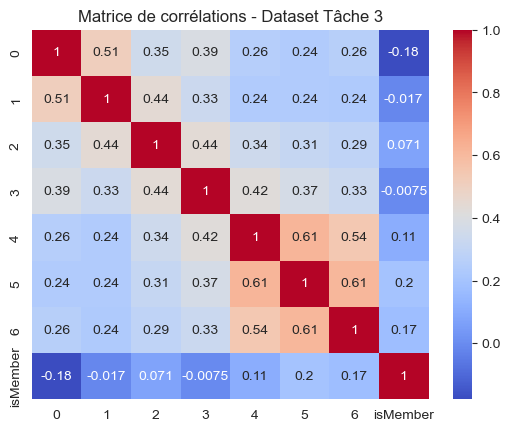

In [176]:
# Visualisation des corrélations
print("Analyse des corrélations temporelles...")
correlation_matrix = trainingSet.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélations - Dataset Tâche 3")
plt.show()
